### Testing script of the CNN model
#### TODO:

+ THink of why accuracy goes down again after dropout 0.1! (might be okay due to fairly small model)
+ Why Adam and not AdamW? 
+ Create requirments file!

**At the end**
+ Make it all in a script to be run from command line
+ Add argument parsing for hyperparameters


### Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

# Local imports
from cnn import SimpleCNN, SimpleAdaptiveCNN
from data.load_cifar import CIFAR10
from train import train_model
from analysis.evaluation import evaluate_model
from data.load_gtsrb import GTSRB_CLASSES, GTSRB


# https://medium.com/@BurtMcGurt/a-practical-guide-to-data-augmentation-in-pytorch-with-examples-and-visualizations-761ad5c2a903
# https://docs.pytorch.org/vision/0.21/transforms.html
import torchvision.transforms as transforms
from torchvision.transforms import v2

import matplotlib.pyplot as plt
import numpy as np

## CIFAR related Area

### Training Area

In [ ]:
# Device selection (prep for potential GPU usage in e.g Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data Augmentation
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomCrop(32, padding=4),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)
])
#train_transforms = None
val_transforms = None

# Create datasets
train_dataset = CIFAR10(split="train", transform=train_transforms)
test_dataset  = CIFAR10(split="test", transform=val_transforms)

# Class names in CIFAR-10
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]

# Create dataloaders
trainloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

# check the "batching"
images, labels = next(iter(trainloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Using device: cpu


/Users/reiterer/MachineLearningWS25/ML_TU_WS25/Exercise3/data/load_cifar.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding="bytes")


Train samples: 50000
Test samples: 10000


/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


In [ ]:
in_channels = 3
num_classes = 10
input_size = 32
base_channels = 32
channel_multiplier = 2
epochs=20

model_selection = {"SimpleCNN_dropout_05": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.5), 
                    "SimpleCNN_dropout_04": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.4),
                    "SimpleCNN_dropout_03": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.3), 
                    "SimpleCNN_dropout_02": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.2), 
                    "SimpleCNN_dropout_01": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.1),   
                    "SimpleCNN_dropout_00": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.0)       
                                }

for model_name, model in model_selection.items():
    print(f"Training model: {model_name}")
    # Set the model to the device (GPU/CPU)
    model = model.to(device)
    print(model)

    # Prepare Loss function and optimizer
    criterion = nn.CrossEntropyLoss() # loss function cross entropy that will be used for calculating the loss during training so that the optimizer can update the weights accordingly (remember backpropagation!)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    print("Starting training...")
    # Train the model
    trained_model = train_model(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=epochs
        )
    print("Training completed.")    

    # Save the trained model and check for exisiting files/dirs 
    Path("cnn_trained_models").mkdir(exist_ok=True)
    file_name = f"cnn_trained_models/{model_name.lower()}_cifar10.pth"
    
    # Check if file exists and append version number
    base_path = Path(file_name)
    if base_path.exists():
        version = 1
        while (base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}").exists():
            version += 1
        file_name = str(base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}")

    torch.save(trained_model.state_dict(), file_name)
    print("Saved trained model to:", file_name)
    
    print("Evaluating trained model on validation set...")
    trained_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = trained_model(images)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Final validation accuracy: {correct / total:.4f}")

    evaluate_model(trained_model, valloader, device=device, class_names=class_names)

    del trained_model

### Show here the training and validation times of our models 
Dropout at 0.5, only things changed is augmentation on/off and the comparison between the two CNN models over number of Epochs

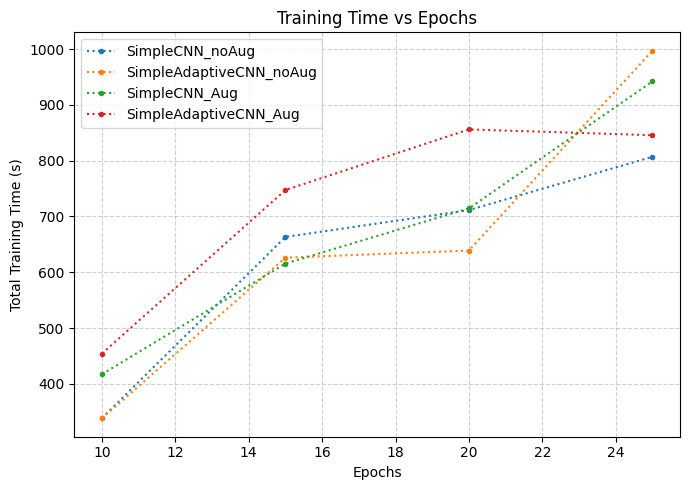

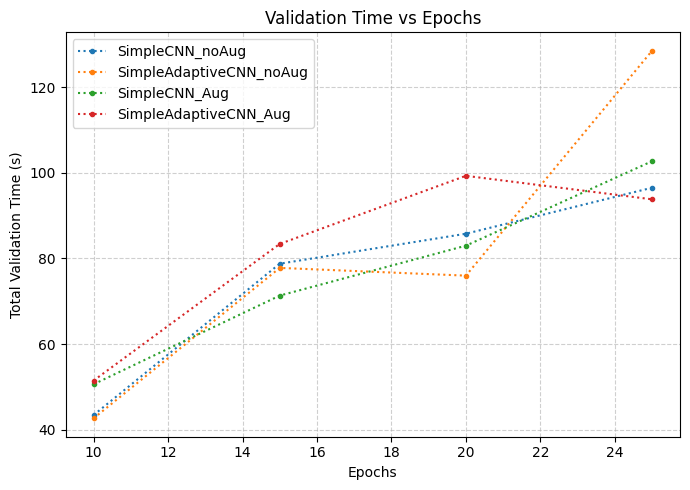

In [ ]:
train_val_times = {   
    #/cnn_trained_models/Ten_epochs and /cnn_training_curves/Ten_epochs
    "SimpleCNN_10Epochs_noAug": {
        "Total Training Time": 338.53 ,
        "Total Validation Time": 43.4 
        } ,
    "SimpleAdaptiveCNN_10Epochs_noAug":{
        "Total Training Time"  : 338.12 ,
        "Total Validation Time": 42.64
        },
    "SimpleCNN_10Epochs_Aug": {
        "Total Training Time"  : 417.16,
        "Total Validation Time": 50.60
        },
    "SimpleAdaptiveCNN_10Epochs_Aug" : {
        "Total Training Time" : 454.24,
        "Total Validation Time": 51.46,
        },

    # /cnn_trained_models/Fifteen_epochs and /cnn_training_curves/Fifteen_epochs
    "SimpleCNN_15Epochs_noAug": {
        "Total Training Time"  : 663.27,
        "Total Validation Time": 78.77
        },
    "SimpleAdaptiveCNN_15Epochs_noAug": {
        "Total Training Time"  : 626.09,
        "Total Validation Time": 77.79
        },
    "SimpleCNN_15Epochs_Aug": {
        "Total Training Time"  : 615.57,
        "Total Validation Time": 71.32
        },
    "SimpleAdaptiveCNN_15Epochs_Aug": {
        "Total Training Time"  : 747.35,
        "Total Validation Time": 83.39
        },

    # /cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twenty_epochs
    "SimpleCNN_20Epochs_noAug": {
        "Total Training Time"  : 711.45,
        "Total Validation Time": 85.77
        },
    "SimpleAdaptiveCNN_20Epochs_noAug": {
        "Total Training Time"  : 638.99,
        "Total Validation Time": 75.98
        },

    "SimpleCNN_20Epochs_Aug": {
        "Total Training Time"  : 714.55,
        "Total Validation Time": 82.98
        },
    "SimpleAdaptiveCNN_20Epochs_Aug": {
        "Total Training Time"  : 856.05,
        "Total Validation Time": 99.3
        },

    # /cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twentyfive_epochs
    "SimpleCNN_25Epochs_noAug":{
        "Total Training Time"  : 807.0,
        "Total Validation Time": 96.52
    },
    "SimpleAdaptiveCNN_25Epochs_noAug": {
        "Total Training Time"  : 997.14,
        "Total Validation Time": 128.53
    },

    "SimpleCNN_25Epochs_Aug": {
        "Total Training Time"  : 942.12,
        "Total Validation Time": 102.72
        },

    "SimpleAdaptiveCNN_25Epochs_Aug": {
        "Total Training Time"  : 845.66,
        "Total Validation Time": 93.81
        }
}


# Epochs
epochs = [10, 15, 20, 25]

# Extracted data in order of epochs above
train_times = {
    "SimpleCNN_noAug": [338.53, 663.27, 711.45, 807.0],
    "SimpleAdaptiveCNN_noAug": [338.12, 626.09, 638.99, 997.14],
    "SimpleCNN_Aug": [417.16, 615.57, 714.55, 942.12],
    "SimpleAdaptiveCNN_Aug": [454.24, 747.35, 856.05, 845.66],
}

val_times = {
    "SimpleCNN_noAug": [43.4, 78.77, 85.77, 96.52],
    "SimpleAdaptiveCNN_noAug": [42.64, 77.79, 75.98, 128.53],
    "SimpleCNN_Aug": [50.60, 71.32, 82.98, 102.72],
    "SimpleAdaptiveCNN_Aug": [51.46, 83.39, 99.3, 93.81],
}

# Training time plot
plt.figure(figsize=(7, 5))
for label, values in train_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Training Time (s)")
plt.title("Training Time vs Epochs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Validation time plot
plt.figure(figsize=(7, 5))
for label, values in val_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Validation Time (s)")
plt.title("Validation Time vs Epochs")
plt.legend()
plt.grid(True,linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Show here the final validation error of the models from before

**Meaning of the suffices**

/cnn_trained_models/Ten_epochs and /cnn_training_curves/Ten_epochs
+ _wo_normalization: There we did not normalize the img in Load_Cifar with std and dev
+ v1: without data augmentation
+ v2: with data augmentation

/cnn_trained_models/Fifteen_epochs and /cnn_training_curves/Fifteen_epochs
+ no suffix: without data augmentation
+ v1: with data augmentation

/cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twenty_epochs
+ no suffix: without data augmentation
+ v1: with data augmentation

/cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twentyfive_epochs
+ no suffix: without data augmentation
+ v1: with data augmentation

In [ ]:
in_channels = 3
num_classes = 10
input_size = 32
base_channels = 32
channel_multiplier = 2

models = {
    'SimpleCNN_10Epochs_noNorm': 'Ten_Epochs/simplecnn_cifar10_wo_normalization.pth', 'SimpleAdaptiveCNN_10Epochs_noNorm': 'Ten_Epochs/simpleadaptivecnn_cifar10_wo_normalization.pth', 
    'SimpleCNN_10Epochs_noAug': 'Ten_Epochs/simplecnn_cifar10_v1.pth', 'SimpleAdaptiveCNN_10Epochs_noAug': 'Ten_Epochs/simpleadaptivecnn_cifar10_v1.pth', 
    'SimpleCNN_10Epochs_Aug': 'Ten_Epochs/simplecnn_cifar10_v2.pth', 'SimpleAdaptiveCNN_10Epochs_Aug': 'Ten_Epochs/simpleadaptivecnn_cifar10_v2.pth', 

    'SimpleCNN_15Epochs_noAug': 'Fifteen_Epochs/simplecnn_cifar10.pth', 'SimpleAdaptiveCNN_15Epochs_noAug': 'Fifteen_Epochs/simpleadaptivecnn_cifar10.pth', 
    'SimpleCNN_15Epochs_Aug': 'Fifteen_Epochs/simplecnn_cifar10_v1.pth', 'SimpleAdaptiveCNN_15Epochs_Aug': 'Fifteen_Epochs/simpleadaptivecnn_cifar10_v1.pth', 

    'SimpleCNN_20Epochs_noAug': 'Twenty_Epochs/simplecnn_cifar10.pth', 'SimpleAdaptiveCNN_20Epochs_noAug': 'Twenty_Epochs/simpleadaptivecnn_cifar10.pth', 
    'SimpleCNN_20Epochs_Aug': 'Twenty_Epochs/simplecnn_cifar10_v1.pth', 'SimpleAdaptiveCNN_20Epochs_Aug': 'Twenty_Epochs/simpleadaptivecnn_cifar10_v1.pth', 

    'SimpleCNN_25Epochs_noAug': 'Twentyfive_Epochs/simplecnn_cifar10.pth', 'SimpleAdaptiveCNN_25Epochs_noAug': 'Twentyfive_Epochs/simpleadaptivecnn_cifar10.pth', 
    'SimpleCNN_25Epochs_Aug': 'Twentyfive_Epochs/simplecnn_cifar10_v1.pth', 'SimpleAdaptiveCNN_25Epochs_Aug': 'Twentyfive_Epochs/simpleadaptivecnn_cifar10_v1.pth'
    }


validation_error = {}
for key, value in models.items():
    if "SimpleCNN" in key:
        trained_model = SimpleCNN(in_channels=in_channels, 
                          num_classes=num_classes, 
                          input_size=input_size,
                          base_channels=base_channels, 
                          channel_multiplier=channel_multiplier,
                          dropout_rate=0.5)
    elif "SimpleAdaptiveCNN" in key:
        trained_model = SimpleAdaptiveCNN(in_channels=in_channels, 
                                  num_classes=num_classes, 
                                  input_size=input_size,
                                  base_channels=base_channels, 
                                  channel_multiplier=channel_multiplier,
                                  dropout_rate=0.5)
        
    filename = value
    trained_model.load_state_dict(torch.load(f"cnn_trained_models/CIFAR/{filename}"))

    trained_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = trained_model(images)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Final validation accuracy for {key}: {correct / total:.4f}")
    validation_error[key] = correct / total

/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Final validation accuracy for SimpleCNN_10Epochs_noNorm: 0.5302
Final validation accuracy for SimpleAdaptiveCNN_10Epochs_noNorm: 0.2965
Final validation accuracy for SimpleCNN_10Epochs_noAug: 0.7710
Final validation accuracy for SimpleAdaptiveCNN_10Epochs_noAug: 0.7199
Final validation accuracy for SimpleCNN_10Epochs_Aug: 0.7587
Final validation accuracy for SimpleAdaptiveCNN_10Epochs_Aug: 0.6832
Final validation accuracy for SimpleCNN_15Epochs_noAug: 0.7693
Final validation accuracy for SimpleAdaptiveCNN_15Epochs_noAug: 0.7493
Final validation accuracy for SimpleCNN_15Epochs_Aug: 0.7845
Final validation accuracy for SimpleAdaptiveCNN_15Epochs_Aug: 0.7214
Final validation accuracy for SimpleCNN_20Epochs_noAug: 0.7741
Final validation accuracy for SimpleAdaptiveCNN_20Epochs_noAug: 0.7632
Final validation accuracy for SimpleCNN_20Epochs_Aug: 0.7992
Final validation accuracy for SimpleAdaptiveCNN_20Epochs_Aug: 0.7477
Final validation accuracy for SimpleCNN_25Epochs_noAug: 0.7732
Final val

{'SimpleCNN_10Epochs_noNorm': 0.5302, 'SimpleAdaptiveCNN_10Epochs_noNorm': 0.2965, 'SimpleCNN_10Epochs_noAug': 0.771, 'SimpleAdaptiveCNN_10Epochs_noAug': 0.7199, 'SimpleCNN_10Epochs_Aug': 0.7587, 'SimpleAdaptiveCNN_10Epochs_Aug': 0.6832, 'SimpleCNN_15Epochs_noAug': 0.7693, 'SimpleAdaptiveCNN_15Epochs_noAug': 0.7493, 'SimpleCNN_15Epochs_Aug': 0.7845, 'SimpleAdaptiveCNN_15Epochs_Aug': 0.7214, 'SimpleCNN_20Epochs_noAug': 0.7741, 'SimpleAdaptiveCNN_20Epochs_noAug': 0.7632, 'SimpleCNN_20Epochs_Aug': 0.7992, 'SimpleAdaptiveCNN_20Epochs_Aug': 0.7477, 'SimpleCNN_25Epochs_noAug': 0.7732, 'SimpleAdaptiveCNN_25Epochs_noAug': 0.7649, 'SimpleCNN_25Epochs_Aug': 0.8104, 'SimpleAdaptiveCNN_25Epochs_Aug': 0.7617}


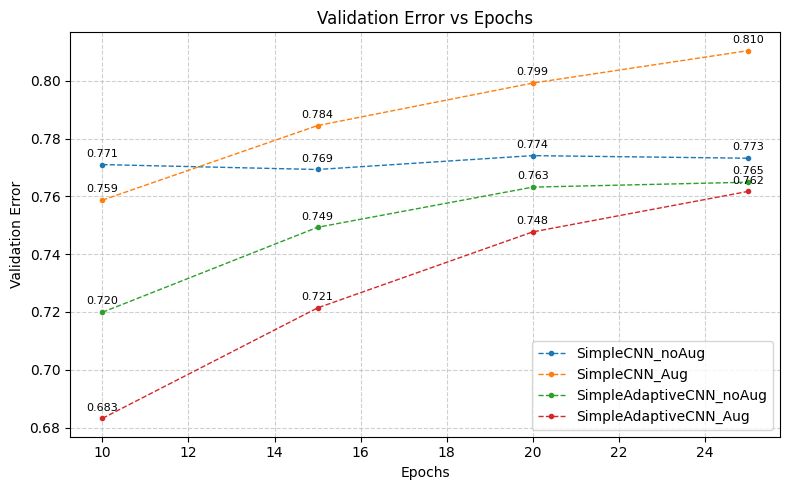

In [62]:
print(validation_error)

epochs = [10, 15, 20, 25]
data = {
    "SimpleCNN_noAug": [0.771, 0.7693, 0.7741, 0.7732],
    "SimpleCNN_Aug": [0.7587, 0.7845, 0.7992, 0.8104],
    "SimpleAdaptiveCNN_noAug": [0.7199, 0.7493, 0.7632, 0.7649],
    "SimpleAdaptiveCNN_Aug": [0.6832, 0.7214, 0.7477, 0.7617],
}

plt.figure(figsize=(8, 5))

for label, values in data.items():
    plt.plot(epochs, values, marker=".", linestyle="--", linewidth=1, label=label)

    for x, y in zip(epochs, values): 
        plt.text(
            x, 
            y + 0.002, 
            f"{y:.3f}",
            ha="center", va="bottom", fontsize=8)
        
plt.xlabel("Epochs")
plt.ylabel("Validation Error")
plt.title("Validation Error vs Epochs")
plt.legend()
plt.grid(linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


### Plotting here the impact of dropout

Dropout tested: [0.5, 0.4, 0.3, 0.2, 0.1, 0.0]. Other "variables" set: Augmentation on and 20 Epochs

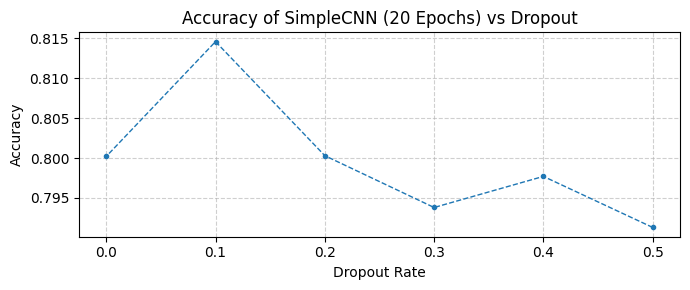

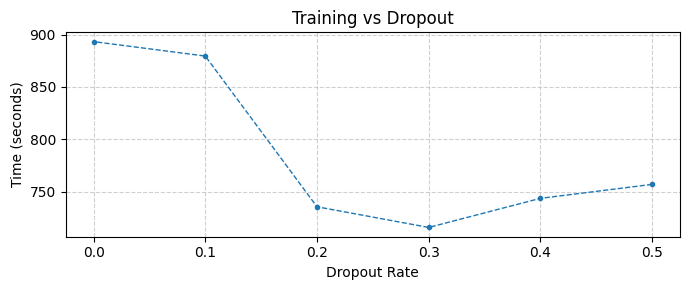

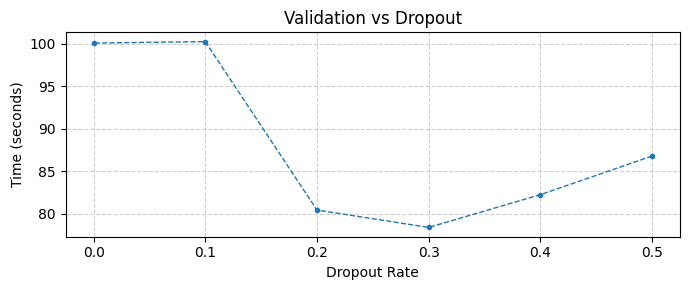

In [ ]:
dropout_model_accuracy = {
    "SimpleCNN_dropout_05": 0.7913, 
    "SimpleCNN_dropout_04": 0.7977, 
    "SimpleCNN_dropout_03": 0.7938,       
    "SimpleCNN_dropout_02": 0.8003,
    "SimpleCNN_dropout_01": 0.8146,   
    "SimpleCNN_dropout_00": 0.8002
    }

# (train, val)        
dropout_model_training_validation_time = {               
    "SimpleCNN_dropout_05": (757.07, 86.77), 
    "SimpleCNN_dropout_04": (743.74, 82.23), 
    "SimpleCNN_dropout_03": (716.00, 78.37),       
    "SimpleCNN_dropout_02": (735.72, 80.42),  
    "SimpleCNN_dropout_01": (879.49, 100.24),
    "SimpleCNN_dropout_00": (893.26, 100.07)
    }


# Extract dropout values from the name
dropout_values = np.array([int(k[-2:]) / 10 for k in dropout_model_accuracy.keys()])
accuracies = np.array(list(dropout_model_accuracy.values()))

# Accuracy Plot
plt.figure(figsize=(7, 3))
plt.plot(dropout_values, accuracies, marker=".", linestyle="--", linewidth=1)

plt.xlabel("Dropout Rate")
plt.ylabel("Accuracy")
plt.title("Accuracy of SimpleCNN (20 Epochs) vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()

# Training & Validation Time Plot
train_times = [v[0] for v in dropout_model_training_validation_time.values()]
val_times = [v[1] for v in dropout_model_training_validation_time.values()]

plt.figure(figsize=(7, 3))
plt.plot(dropout_values, train_times, marker=".", linestyle="--", linewidth=1, label="Training Time")

plt.xlabel("Dropout Rate")
plt.ylabel("Time (seconds)")
plt.title("Training vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(dropout_values, val_times, marker=".", linestyle="--", linewidth=1, label="Validation Time")

plt.xlabel("Dropout Rate")
plt.ylabel("Time (seconds)")
plt.title("Validation vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()

## 2nd dataset

### Training Area

In [5]:
# Device selection (prep for potential GPU usage in e.g Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data Augmentation
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomCrop(32, padding=4),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)
])
#train_transforms = None
val_transforms = None

training_path = "../data/GTSRB/Final_Training/Images"
testing_path = "../data/GTSRB/Final_Test/Images"

# Create datasets
train_dataset = GTSRB(base_path=training_path, split="train", transform=None)
test_dataset  = GTSRB(base_path=testing_path, split="test", transform=None)

# Class names in GTSRB
class_names = GTSRB_CLASSES

# Create dataloaders
trainloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

# check the "batching"
images, labels = next(iter(trainloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Using device: cpu
Loading GTSRB (train) from ../data/GTSRB/Final_Training/Images...
Loading GTSRB (test) from ../data/GTSRB/Final_Test/Images...
Train samples: 39209
Test samples: 12630


/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Image batch shape: torch.Size([128, 3, 64, 64])
Label batch shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


In [ ]:
in_channels = 3
num_classes = len(GTSRB_CLASSES)
input_size = 64
base_channels = 64
channel_multiplier = 2
epochs=5

model_selection = {
                    "SimpleCNN_dropout_01": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.1)     
                                }

for model_name, model in model_selection.items():
    print(f"Training model: {model_name}")
    # Set the model to the device (GPU/CPU)
    model = model.to(device)
    print(model)

    # Prepare Loss function and optimizer
    criterion = nn.CrossEntropyLoss() # loss function cross entropy that will be used for calculating the loss during training so that the optimizer can update the weights accordingly (remember backpropagation!)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    print("Starting training...")
    # Train the model
    trained_model = train_model(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=epochs
        )
    print("Training completed.")    

    # Save the trained model and check for exisiting files/dirs 
    Path("cnn_trained_models").mkdir(exist_ok=True)
    file_name = f"cnn_trained_models/{model_name.lower()}_cifar10.pth"
    
    # Check if file exists and append version number
    base_path = Path(file_name)
    if base_path.exists():
        version = 1
        while (base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}").exists():
            version += 1
        file_name = str(base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}")

    torch.save(trained_model.state_dict(), file_name)
    print("Saved trained model to:", file_name)
    
    print("Evaluating trained model on validation set...")
    trained_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = trained_model(images)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Final validation accuracy: {correct / total:.4f}")

    evaluate_model(trained_model, valloader, device=device, class_names=class_names)

    del trained_model

Training model: SimpleCNN_dropout_01
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=16384, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=43, bias=True)
  )
)
Starting training...

Epoch 1/5


Training:   0%|          | 0/307 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Training:  34%|███▍      | 104/307 [01:27<04:23,  1.30s/it]